# **Data Loading and Initial Checks**

## **1. Importing Libraries**
- `numpy`: For numerical operations.
- `pandas`: For data handling and manipulation.
- `matplotlib.pyplot` & `seaborn`: For visualization.

## **2. Loading the Dataset**
- We load the dataset from `predictive_maintenance.csv` using `pandas.read_csv()`.

## **3. Initial Data Checks**
- `data.info()` provides an overview of dataset structure, including:
  - Column names
  - Non-null values
  - Data types

- Duplicate check for `Product ID`:
  - If `True`, duplicates exist.
  - If `False`, all `Product ID`s are unique.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Import data
data_path = 'predictive_maintenance.csv'
data = pd.read_csv(data_path)

n = data.shape[0]       #number of rows in dataset

# First checks
print('Features non-null values and data type:')
data.info()             #provides information for dataset structure, non-null values and datatypes


print('Check for duplicate values:',
      data['Product ID'].unique().shape[0]!=n)

Features non-null values and data type:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Target                   10000 non-null  int64  
 9   Failure Type             10000 non-null  object 
dtypes: float64(3), int64(4), object(3)
memory usage: 781.4+ KB
Check for duplicate values: False


# **Data Preprocessing: Type Conversion & Renaming**

- Converted `Tool wear [min]` and `Rotational speed [rpm]` to `float64` for consistency.  
- Renamed columns to remove unit annotations for better readability.


In [3]:
# Set numeric columns dtype to float
data['Tool wear [min]'] = data['Tool wear [min]'].astype('float64')
data['Rotational speed [rpm]'] = data['Rotational speed [rpm]'].astype('float64')

# Rename features
data.rename(mapper={'Air temperature [K]': 'Air temperature',
                    'Process temperature [K]': 'Process temperature',
                    'Rotational speed [rpm]': 'Rotational speed',
                    'Torque [Nm]': 'Torque',
                    'Tool wear [min]': 'Tool wear'}, axis=1, inplace=True)

# **Processing `Product ID`**
- Removed the first character from `Product ID`.
- Converted `Product ID` to numeric format for analysis.


In [4]:
# Remove first character and set to numeric dtype
data['Product ID'] = data['Product ID'].apply(lambda x: x[1:])
data['Product ID'] = pd.to_numeric(data['Product ID'])


# **Dropping ID Columns**
- Removed `UDI` and `Product ID` as they are not needed for analysis.


In [5]:
# Drop ID columns
df = data.copy()
df.drop(columns=['UDI','Product ID'], inplace=True)

# **Feature Selection & Random Failure Filtering**
- Selected numerical features and categorical `'Type'` for analysis.
- Defined target variables: `'Target'` (failure occurrence) & `'Failure Type'` (failure category).
- Extracted rows where `'Failure Type'` is `'Random Failures'`.


In [6]:
# Create lists of features and target names
features = [col for col in df.columns
            if df[col].dtype=='float64' or col =='Type']
target = ['Target','Failure Type']

# Portion of data where RNF=1
idx_RNF = df.loc[df['Failure Type']=='Random Failures'].index
df.loc[idx_RNF,target]

,Target,Failure Type
1221,0,Random Failures
1302,0,Random Failures
1748,0,Random Failures
2072,0,Random Failures
2559,0,Random Failures
3065,0,Random Failures
3452,0,Random Failures
5471,0,Random Failures
5489,0,Random Failures
5495,0,Random Failures


# **Removing Random Failures**
- Identified and counted instances where `'Failure Type'` was `'Random Failures'`.
- Removed these observations to improve failure type classification.


In [7]:
first_drop = df.loc[idx_RNF,target].shape[0]
print('Number of observations where RNF=1 but Machine failure=0:',first_drop)

# Drop corresponding observations and RNF column
df.drop(index=idx_RNF, inplace=True)

Number of observations where RNF=1 but Machine failure=0: 18


# **Removing Ambiguous Machine Failures**
- Identified cases where `Target == 1` (machine failure) but `Failure Type == 'No Failure'`, which is inconsistent.
- Counted and displayed these ambiguous observations.
- Removed them from the dataset to maintain data integrity.


In [8]:
# Portion of data where Machine failure=1 but no failure cause is specified
idx_ambiguous = df.loc[(df['Target']==1) &
                       (df['Failure Type']=='No Failure')].index

second_drop = df.loc[idx_ambiguous].shape[0]
print('Number of ambiguous observations:', second_drop)

display(df.loc[idx_ambiguous,target])
df.drop(index=idx_ambiguous, inplace=True)

Number of ambiguous observations: 9


,Target,Failure Type
1437,1,No Failure
2749,1,No Failure
4044,1,No Failure
4684,1,No Failure
5536,1,No Failure
5941,1,No Failure
6478,1,No Failure
8506,1,No Failure
9015,1,No Failure


# **Finalizing Data Cleaning**
- Calculated the percentage of observations removed during preprocessing.
- Reset the index after dropping inconsistent rows.
- Updated dataset size (`n`) for further analysis.


In [9]:
# Global percentage of removed observations
print('Global percentage of removed observations:',
     (100*(first_drop+second_drop)/n))

df.reset_index(drop=True, inplace=True)   # Reset index
n = df.shape[0]

Global percentage of removed observations: 0.27


In [10]:
df.describe()

,Air temperature,Process temperature,Rotational speed,Torque,Tool wear,Target
count,9973.000000,9973.000000,9973.000000,9973.000000,9973.000000,9973.000000
mean,300.003259,310.004031,1538.893212,39.978993,107.921087,0.033089
std,2.000548,1.483692,179.412171,9.966805,63.649152,0.178879
min,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000
25%,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000
50%,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000
75%,301.500000,311.100000,1612.000000,46.700000,162.000000,0.000000
max,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000


# **Histograms of Numeric Features**
- Visualized distributions of numerical features using histograms.
- Helps in understanding skewness, spread, and presence of outliers.


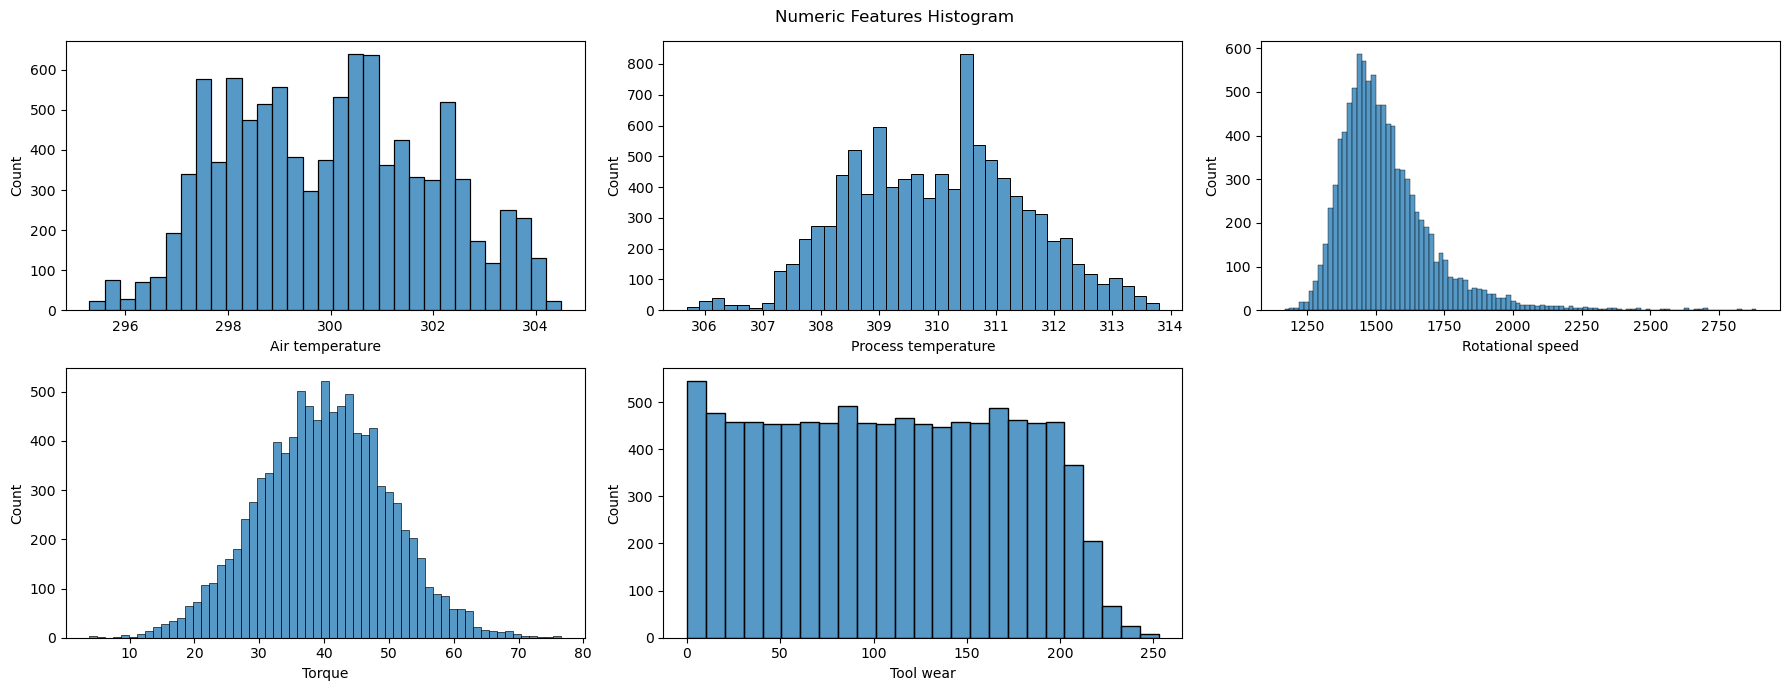

In [10]:
num_features = [feature for feature in features if df[feature].dtype == 'float64']

# Determine number of plots required
num_plots = len(num_features)
rows = (num_plots // 3) + (num_plots % 3 > 0)  # Adjust rows dynamically

# Create subplots grid
fig, axs = plt.subplots(nrows=rows, ncols=3, figsize=(18, 7))
fig.suptitle('Numeric Features Histogram')

# Flatten axs array for easier indexing (handles cases where rows < 2)
axs = axs.flatten()

# Plot histograms
for j, feature in enumerate(num_features):
    sns.histplot(ax=axs[j], data=df, x=feature)

# Hide any unused subplots
for j in range(num_plots, len(axs)):
    fig.delaxes(axs[j])  # Remove extra empty subplots

plt.tight_layout()
plt.show()


# **Failure Causes and Distribution**
- Extracted failure cases from the dataset.
- Calculated the percentage of each failure type.
- Plotted a **pie chart** to visualize machine failure causes.


Failures percentage in data: 3.31


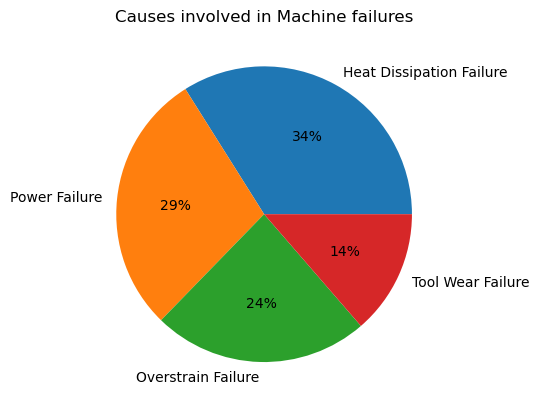

In [12]:
# Portion of df where there is a failure and causes percentage
idx_fail = df.loc[df['Failure Type'] != 'No Failure'].index
df_fail = df.loc[idx_fail]
df_fail_percentage = 100*df_fail['Failure Type'].value_counts()/df_fail['Failure Type'].shape[0]
print('Failures percentage in data:',
      round(100*df['Target'].sum()/n,2))
# Pie plot
plt.title('Causes involved in Machine failures')
plt.pie(x=df_fail_percentage.array, labels=df_fail_percentage.index.array,
        colors=sns.color_palette('tab10')[0:4], autopct='%.0f%%')
plt.show()

In [11]:
# Assuming df is the original dataset after preprocessing
df_res = df.copy()  # If preprocessing is completed, make a copy for further processing


# **Feature Encoding and Standardization**
- **Encoded categorical variables** (`Type` and `Failure Type`) into numerical values.
- **Standardized numerical features** using `StandardScaler` to ensure all features have a mean of 0 and variance of 1.
- Improves model performance by normalizing different feature scales.


In [12]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

sc = StandardScaler()
type_dict = {'L': 0, 'M': 1, 'H': 2}
cause_dict = {'No Failure': 0,
              'Power Failure': 1,
              'Overstrain Failure': 2,
              'Heat Dissipation Failure': 3,
              'Tool Wear Failure': 4}
df_pre = df_res.copy()

# Encoding
df_pre['Type'].replace(to_replace=type_dict, inplace=True)
df_pre['Failure Type'].replace(to_replace=cause_dict, inplace=True)

# Scaling
df_pre[num_features] = sc.fit_transform(df_pre[num_features]) 

# **Principal Component Analysis (PCA)**
- **Applied PCA** on standardized numerical features.
- **Explained variance ratio** analyzed for each principal component.
- **First 3 principal components retain most variance**, aiding dimensionality reduction.


In [13]:
pca = PCA(n_components=len(num_features))
X_pca = pd.DataFrame(data=pca.fit_transform(df_pre[num_features]), columns=['PC'+str(i+1) for i in range(len(num_features))])
var_exp = pd.Series(data=100*pca.explained_variance_ratio_, index=['PC'+str(i+1) for i in range(len(num_features))])
print('Explained variance ratio per component:', round(var_exp,2), sep='\n')
print('Explained variance ratio with 3 components: '+str(round(var_exp.values[:3].sum(),2)))

Explained variance ratio per component:
PC1    38.25
PC2    36.78
PC3    19.99
PC4     2.53
PC5     2.45
dtype: float64
Explained variance ratio with 3 components: 95.02


### Applying PCA and Renaming Components  

- **PCA (Principal Component Analysis)** is applied with `n_components=3` to reduce dimensionality while preserving maximum variance.  
- The transformed dataset consists of **three principal components (PC1, PC2, and PC3)**.  
- To improve interpretability, we rename these components based on their dominant contributing features:  
  - **PC1 → Temperature**  
  - **PC2 → Power**  
  - **PC3 → Tool Wear**  
- This allows us to retain the advantages of PCA while making the new features more meaningful in the context of the dataset.  


In [14]:
pca3 = PCA(n_components=3)
X_pca3 = pd.DataFrame(data=pca3.fit_transform(df_pre[num_features]), columns=['PC1','PC2','PC3'])


In [15]:
X_pca3.rename(mapper={'PC1':'Temperature',
                      'PC2':'Power',
                      'PC3':'Tool Wear'}, axis=1, inplace=True)

### Correlation Heatmap  

- The heatmap visualizes the **correlation** between numerical features.  
- The **upper triangle is masked** to avoid redundancy.  
- Colors indicate correlation strength:
  - **Dark brown** → Strong negative correlation  
  - **Dark blue** → Strong positive correlation  
  - **Neutral color** → Weak or no correlation  
- This helps identify **relationships** between features for better model insights.  


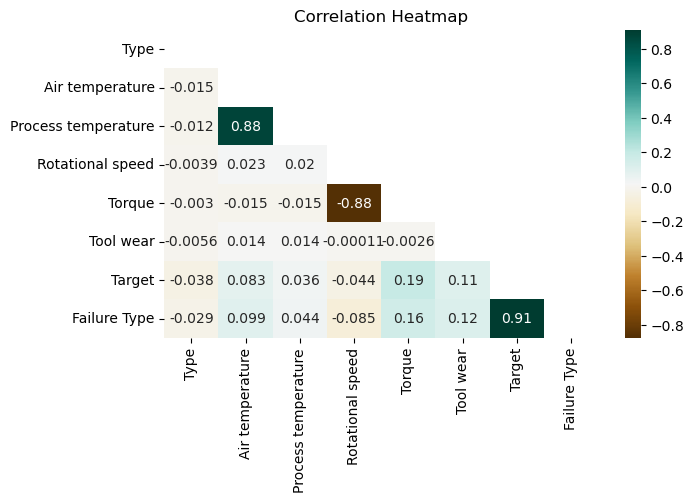

In [16]:
plt.figure(figsize=(7,4))
sns.heatmap(data=df_pre.corr(), mask=np.triu(df_pre.corr()), annot=True, cmap='BrBG')
plt.title('Correlation Heatmap')
plt.show()


### Train-Validation-Test Split: Why is it Important?  

1. **Training Set** → Used to train the model.  
2. **Validation Set** → Helps tune hyperparameters and prevent overfitting.  
3. **Test Set** → Evaluates the model's real-world performance.  

This approach ensures the model generalizes well to unseen data and avoids bias.  


In [18]:
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, fbeta_score
from sklearn.metrics import confusion_matrix, make_scorer
#from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
#from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
import time

# train-validation-test split
X, y = df_pre[features], df_pre[['Target','Failure Type']]
X_trainval, X_test, y_trainval, y_test = train_test_split(X, y, test_size=0.1, stratify=df_pre['Failure Type'], random_state=0)
X_train, X_val, y_train, y_val = train_test_split(X_trainval, y_trainval, test_size=0.11, stratify=y_trainval['Failure Type'], random_state=0)

# **Model Training & Evaluation Functions**

This section defines utility functions for training, tuning, and evaluating machine learning models for **predictive maintenance**.

### **1. `eval_preds` - Evaluate Model Performance**  
Computes key metrics for **binary** and **multi-class** classification:  
- **Accuracy (ACC)**, **AUC**, **F1-score (F1)**, **F2-score (F2)**  
- **Confusion Matrix (CM)** to analyze misclassifications.

### **2. `tune_and_fit` - Hyperparameter Tuning & Model Training**  
Uses **GridSearchCV** to find the best parameters and train models.  
Optimizes using **F2-score**, reports **best hyperparameters** and **training time**.

### **3. `predict_and_evaluate` - Make Predictions & Compute Metrics**  
- Applies trained models to test data.  
- Returns **predictions**, **confusion matrices**, and **performance scores** for comparison.

### **4. `fit_models` - Train Multiple Models**  
- Trains classifiers on `X_train, y_train`, evaluates on `X_val, y_val`.  
- Returns a **metrics DataFrame** summarizing model performance.

These functions streamline **training, tuning, and evaluating classifiers** for failure detection. 🚀

In [19]:
"""User-defined function: Evaluate cm, accurcay, AUC, F1 for a given classifier
- model, fitted estimator.
- X, data used to estimate class probabilities (paired with y_true)
- y_true, ground truth with two columns
- y_pred, predictions
- task = 'binary','multi_class'
"""
def eval_preds(model,X,y_true,y_pred,task):
    if task == 'binary':
        # Extract task target
        y_true = y_true['Target']
        cm = confusion_matrix(y_true, y_pred)
        # Probability of the minority class
        proba = model.predict_proba(X)[:,1]
        # Metrics
        acc = accuracy_score(y_true, y_pred)
        auc = roc_auc_score(y_true, proba)
        f1 = f1_score(y_true, y_pred, pos_label=1)
        f2 = fbeta_score(y_true, y_pred, pos_label=1, beta=2)
    elif task == 'multi_class':
        y_true = y_true['Failure Type']
        cm = confusion_matrix(y_true, y_pred)
        proba = model.predict_proba(X)
        # Metrics
        acc = accuracy_score(y_true, y_pred)
        auc = roc_auc_score(y_true, proba, multi_class='ovr', average='weighted')
        f1 = f1_score(y_true, y_pred, average='weighted')
        f2 = fbeta_score(y_true, y_pred, beta=2, average='weighted')
    metrics = pd.Series(data={'ACC':acc, 'AUC':auc, 'F1':f1, 'F2':f2})
    metrics = round(metrics,3)
    return cm, metrics



"""User-defined function: Fits one estimator using GridSearch to search for the best parameters
- clf, estimator
- X, y = X_train, y_train
- params, parameters grid for GridSearch
- task = 'binary','multi_class'
"""
def tune_and_fit(clf,X,y,params,task):
    if task=='binary':
        f2_scorer = make_scorer(fbeta_score, pos_label=1, beta=2)
        start_time = time.time()
        grid_model = GridSearchCV(clf, param_grid=params,
                                cv=5, scoring=f2_scorer)
        grid_model.fit(X, y['Target'])
    elif task=='multi_class':
        f2_scorer = make_scorer(fbeta_score, beta=2, average='weighted')
        start_time = time.time()
        grid_model = GridSearchCV(clf, param_grid=params,
                              cv=5, scoring=f2_scorer)
        grid_model.fit(X, y['Failure Type'])
        
    print('Best params:', grid_model.best_params_)
    # Print training times
    train_time = time.time()-start_time
    mins = int(train_time//60)
    print('Training time: '+str(mins)+'m '+str(round(train_time-mins*60))+'s')
    return grid_model



"""User-defined function: Makes predictions using the tuned classifiers.
Then uses eval_preds to compute the relative metrics. Returns:
- y_pred, DataFrame containing the predictions of each model
- cm_list, confusion matrix list
- metrics, DataFrame containing the metrics
Input:
- fitted_models, fitted estimators
- X, data used to make predictions
- y_true, true values for target
- clf_str, list containing estimators names
- task = 'binary','multi_class'
"""
def predict_and_evaluate(fitted_models,X,y_true,clf_str,task):
    cm_dict = {key: np.nan for key in clf_str}
    metrics = pd.DataFrame(columns=clf_str)
    y_pred = pd.DataFrame(columns=clf_str)
    for fit_model, model_name in zip(fitted_models,clf_str):
        # Update predictions
        y_pred[model_name] = fit_model.predict(X)
        # Metrics
        if task == 'binary':
            cm, scores = eval_preds(fit_model,X,y_true,
                                     y_pred[model_name],task)
        elif task == 'multi_class':
            cm, scores = eval_preds(fit_model,X,y_true,
                                     y_pred[model_name],task)
        # Update Confusion matrix and metrics
        cm_dict[model_name] = cm
        metrics[model_name] = scores
    return y_pred, cm_dict, metrics



"""User-defined function: Fit the estimators on multiple classifiers
- clf, estimators
- clf_str, list containing estimators names
- X_train,y_train, data used to fit models
- X_val,y_val, data used to validate models
"""

def fit_models(clf,clf_str,X_train,X_val,y_train,y_val):
    metrics = pd.DataFrame(columns=clf_str)
    for model, model_name in zip(clf, clf_str):
        model.fit(X_train,y_train['Target'])
        y_val_pred = model.predict(X_val)
        metrics[model_name] = eval_preds(model,X_val,y_val,y_val_pred,'binary')[1]
    return metrics

### Model Training with Feature Engineering  

This cell trains multiple machine learning models on different feature variations to analyze their impact on classification performance.  

#### **1. Model Initialization**  
- Logistic Regression (LR), K-Nearest Neighbors (KNN), Support Vector Classifier (SVC), and XGBoost (XGB) are initialized.  

#### **2. Feature Engineering & Training**  
- **Original Features:** Models are trained on raw data.  
- **Temperature Feature:** `Process Temperature` and `Air Temperature` are replaced with `Temperature = Process Temperature × Air Temperature`.  
- **Power Feature:** `Rotational Speed` and `Torque` are replaced with `Power = Rotational Speed × Torque`.  
- **Both Features:** Combines both transformations.  

#### **3. Performance Evaluation**  
- Models are trained and evaluated using classification metrics (Accuracy, F1-score, AUC, etc.).  
- A **bar plot** visualizes performance across different feature sets, helping identify the best transformation.  

#### **Objective:**  
Determine which feature engineering approach improves failure classification accuracy.  


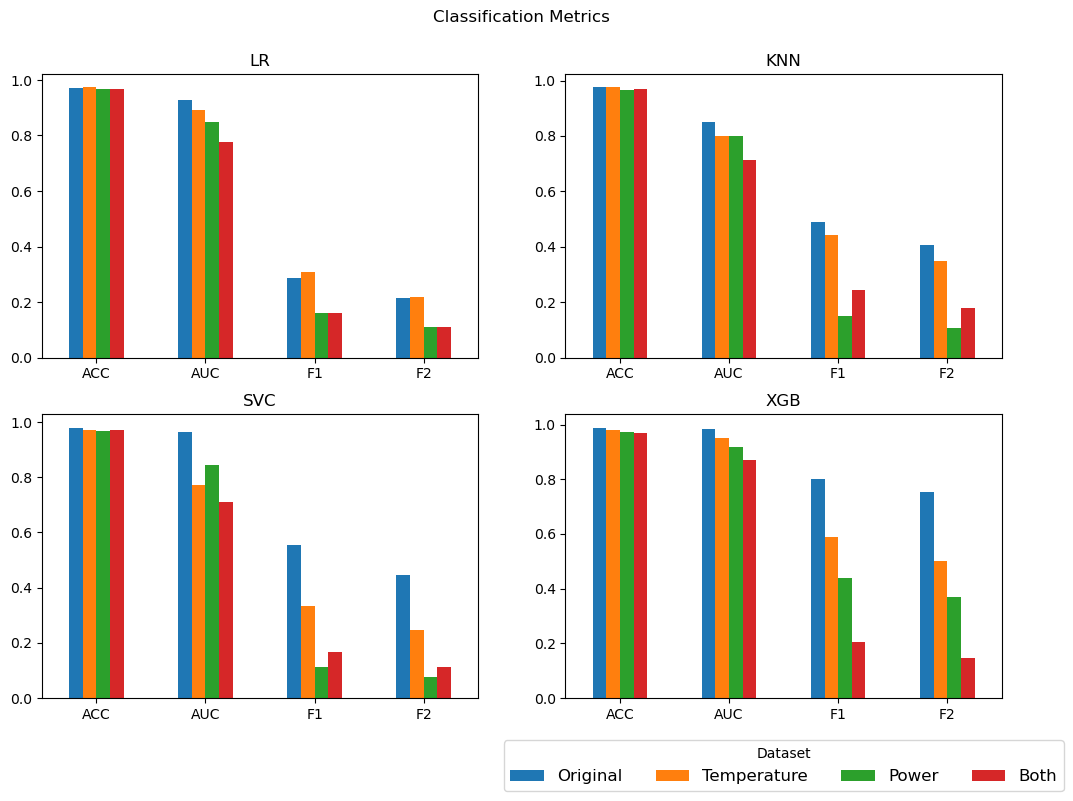

In [24]:
# Models
lr = LogisticRegression()
knn = KNeighborsClassifier()
svc = SVC(probability=True)
#rfc = RandomForestClassifier()
xgb = XGBClassifier() 

clf = [lr,knn,svc,xgb]
clf_str = ['LR','KNN','SVC','XGB'] 

# Fit on raw train
metrics_0 = fit_models(clf,clf_str,X_train,X_val,y_train,y_val)

# Fit on temperature product train
XX_train = X_train.drop(columns=['Process temperature','Air temperature'])
XX_val = X_val.drop(columns=['Process temperature','Air temperature'])
XX_train['Temperature']= X_train['Process temperature']*X_train['Air temperature']
XX_val['Temperature'] = X_val['Process temperature']*X_val['Air temperature']
metrics_1 = fit_models(clf,clf_str,XX_train,XX_val,y_train,y_val)

# Fit on power product train
XX_train = X_train.drop(columns=['Rotational speed','Torque'])
XX_val = X_val.drop(columns=['Rotational speed','Torque'])
XX_train['Power'] = X_train['Rotational speed']*X_train['Torque']
XX_val['Power'] = X_val['Rotational speed']*X_val['Torque']     
metrics_2 = fit_models(clf,clf_str,XX_train,XX_val,y_train,y_val)

# Fit on both products train
XX_train = X_train.drop(columns=['Process temperature','Air temperature','Rotational speed','Torque'])
XX_val = X_val.drop(columns=['Process temperature','Air temperature','Rotational speed','Torque'])
XX_train['Temperature']= X_train['Process temperature']*X_train['Air temperature']
XX_val['Temperature']= X_val['Process temperature']*X_val['Air temperature']
XX_train['Power'] = X_train['Rotational speed']*X_train['Torque']
XX_val['Power'] = X_val['Rotational speed']*X_val['Torque']       
metrics_3 = fit_models(clf,clf_str,XX_train,XX_val,y_train,y_val)

# classification metrics barplot
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(12, 8))  # 2x2 grid for 4 models
fig.suptitle('Classification Metrics')

for j, model in enumerate(clf_str):  
    ax = axs[j//2, j % 2]  # Adjust subplot positioning in 2x2 grid
    model_metrics = pd.DataFrame(data=[metrics_0[model], metrics_1[model], metrics_2[model], metrics_3[model]])
    model_metrics.index = ['Original', 'Temperature', 'Power', 'Both']
    
    model_metrics.transpose().plot(ax=ax, kind='bar', rot=0)
    ax.title.set_text(model)
    ax.get_legend().remove()

# Add legend at the bottom
fig.subplots_adjust(top=0.9, left=0.1, right=0.9, bottom=0.12)
axs.flatten()[-1].legend(title='Dataset', loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=4, fontsize=12)

plt.show()


In [25]:
# Create a DataFrame to store accuracy values
accuracy_table = pd.DataFrame({
    'Original': [metrics_0[model]['ACC'] for model in clf_str],
    'Temperature': [metrics_1[model]['ACC'] for model in clf_str],
    'Power': [metrics_2[model]['ACC'] for model in clf_str],
    'Both': [metrics_3[model]['ACC'] for model in clf_str]
}, index=clf_str)

# Display the table
print("Model Accuracy Across Different Feature Variations:")
display(accuracy_table.style.set_caption("Model Accuracy Table").format("{:.3f}"))


Model Accuracy Across Different Feature Variations:


,Original,Temperature,Power,Both
LR,0.970,0.973,0.969,0.969
KNN,0.975,0.975,0.966,0.969
SVC,0.979,0.972,0.969,0.970
XGB,0.988,0.979,0.972,0.969


### **Logistic Regression Model Analysis**
- **Model Training & Prediction:** Trained LR model on `X_train`, predicted on `X_val` and `X_test`.
- **Performance Evaluation:** Computed metrics using `eval_preds()`, including precision, recall, and F1-score.
- **Confusion Matrices:** Visualized classification results for validation and test sets using heatmaps.
- **Feature Importance:** Ranked features using **odds ratios** (`exp(coef)`) to interpret their impact on failure prediction.


Validation set metrics:
ACC    0.970
AUC    0.928
F1     0.286
F2     0.213
dtype: float64
Test set metrics:
ACC    0.977
AUC    0.912
F1     0.465
F2     0.352
dtype: float64


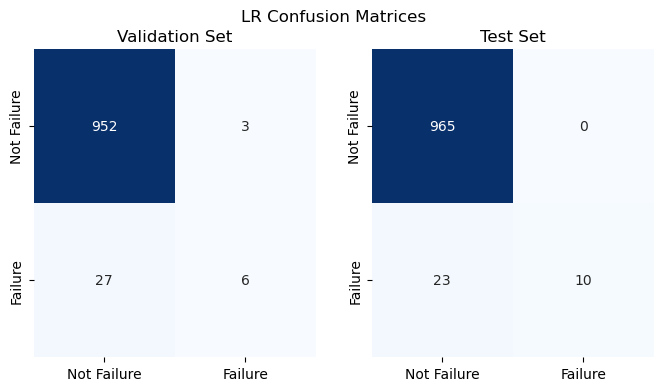

,feature,odds
4,Torque,15.649936
3,Rotational speed,7.568350
1,Air temperature,4.286363
5,Tool wear,2.316018
0,Type,0.676489
2,Process temperature,0.365872


In [26]:
# Make predictions
lr = LogisticRegression(random_state=0)
lr.fit(X_train, y_train['Target'])
y_val_lr = lr.predict(X_val)
y_test_lr = lr.predict(X_test)

# Metrics
cm_val_lr, metrics_val_lr = eval_preds(lr,X_val,y_val,y_val_lr,'binary')
cm_test_lr, metrics_test_lr = eval_preds(lr,X_test,y_test,y_test_lr,'binary')
print('Validation set metrics:',metrics_val_lr, sep='\n')
print('Test set metrics:',metrics_test_lr, sep='\n')

cm_labels = ['Not Failure', 'Failure']
cm_lr = [cm_val_lr, cm_test_lr]
# Show Confusion Matrices
fig, axs = plt.subplots(ncols=2, figsize=(8,4))
fig.suptitle('LR Confusion Matrices')
for j, title in enumerate(['Validation Set', 'Test Set']):
    ax = axs[j]
    sns.heatmap(ax=ax, data=cm_lr[j], annot=True,
              fmt='d', cmap='Blues', cbar=False)
    axs[j].title.set_text(title)
    axs[j].set_xticklabels(cm_labels)
    axs[j].set_yticklabels(cm_labels)
plt.show()

# Odds for interpretation
d = {'feature': X_train.columns, 'odds': np.exp(lr.coef_[0])}
odds_df = pd.DataFrame(data=d).sort_values(by='odds', ascending=False)
odds_df

### **Hyperparameter Tuning & Model Training**
- **Models Used:** KNN, SVC, XGBoost (RFC commented out).
- **Hyperparameter Tuning:**  
  - Used **GridSearchCV** for parameter tuning.
  - Defined parameter grids for each model.
- **Training Process:**  
  - Iterated through models, performing **GridSearch** to find optimal hyperparameters.
  - Stored fitted models for later evaluation.


In [28]:
# Models
knn = KNeighborsClassifier()
svc = SVC()
#rfc = RandomForestClassifier()
xgb = XGBClassifier() 
clf = [knn,svc,xgb]
clf_str = ['KNN','SVC','RFC','XGB']

# Parameter grids for GridSearch
knn_params = {'n_neighbors':[1,3,5,8,10]}
svc_params = {'C': [1, 10, 100],
              'gamma': [0.1,1],
              'kernel': ['rbf'],
              'probability':[True],
              'random_state':[0]}
#rfc_params = {'n_estimators':[100,300,500,700],
 #             'max_depth':[5,7,10],
  #            'random_state':[0]}
xgb_params = {'n_estimators':[300,500,700],
              'max_depth':[5,7],
              'learning_rate':[0.01,0.1],
              'objective':['binary:logistic']}
params = pd.Series(data=[knn_params,svc_params,xgb_params],
                   index=clf)

# Tune hyperparameters with GridSearch (estimated time 8m)
print('GridSearch start')
fitted_models_binary = []
for model, model_name in zip(clf, clf_str):
    print('Training '+str(model_name))
    fit_model = tune_and_fit(model,X_train,y_train,params[model],'binary')
    fitted_models_binary.append(fit_model)

GridSearch start
Training KNN
Best params: {'n_neighbors': 1}
Training time: 0m 3s
Training SVC
Best params: {'C': 100, 'gamma': 0.1, 'kernel': 'rbf', 'probability': True, 'random_state': 0}
Training time: 1m 24s
Training RFC
Best params: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 500, 'objective': 'binary:logistic'}
Training time: 1m 7s
